# Basics (Miscellany)

## Simulation

Let's generate a random sequence of +/- 1, then calculate its running sums, and visualize them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import random

np.random.seed(1001)  # set the seed for reproducibility

# Generate 100 draws of ±1
draws = np.random.choice([1, -1], size=100)

# Compute cumulative sum
cumulative = np.cumsum(draws)

print(cumulative)

[-1 -2 -3 -2 -1 -2 -1  0  1  0 -1 -2 -1  0 -1 -2 -1 -2 -3 -4 -5 -4 -3 -2
 -1 -2 -3 -2 -1  0 -1  0 -1  0  1  0  1  2  1  0 -1  0  1  2  1  2  1  0
  1  2  1  0 -1 -2 -1  0  1  0  1  0  1  0  1  0  1  2  1  2  1  2  1  2
  3  2  3  4  5  4  5  4  5  6  5  6  7  8  9 10 11 12 11 12 13 12 13 12
 11 10 11 10]


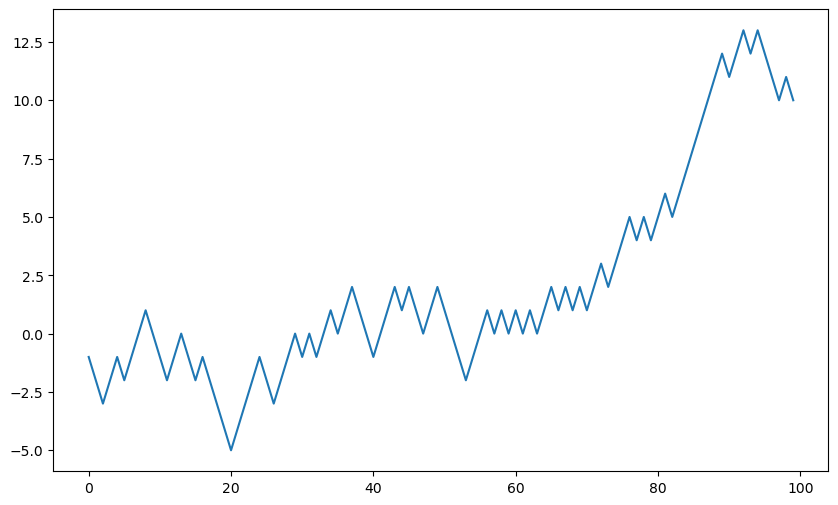

In [3]:
plt.figure(figsize=(10, 6))
plt.plot(cumulative)
plt.show()

## Logarithm

Why take logs?

There are many good reasons to take logs in finance. Here are a few:
1. Addition rather than multiplication
2. Scaling
3. Percentage change

### Price vs. Log price

Let's look at prices and log prices.

In [4]:
price = [100, 200, 300, 200, 400]
time = [1, 2, 3, 4 , 5]
df = pd.DataFrame({"price": price}, index=time)
df

,price
1,100
2,200
3,300
4,200
5,400


In [5]:
df["log_price"] = np.log(df["price"])
df

,price,log_price
1,100,4.605170
2,200,5.298317
3,300,5.703782
4,200,5.298317
5,400,5.991465


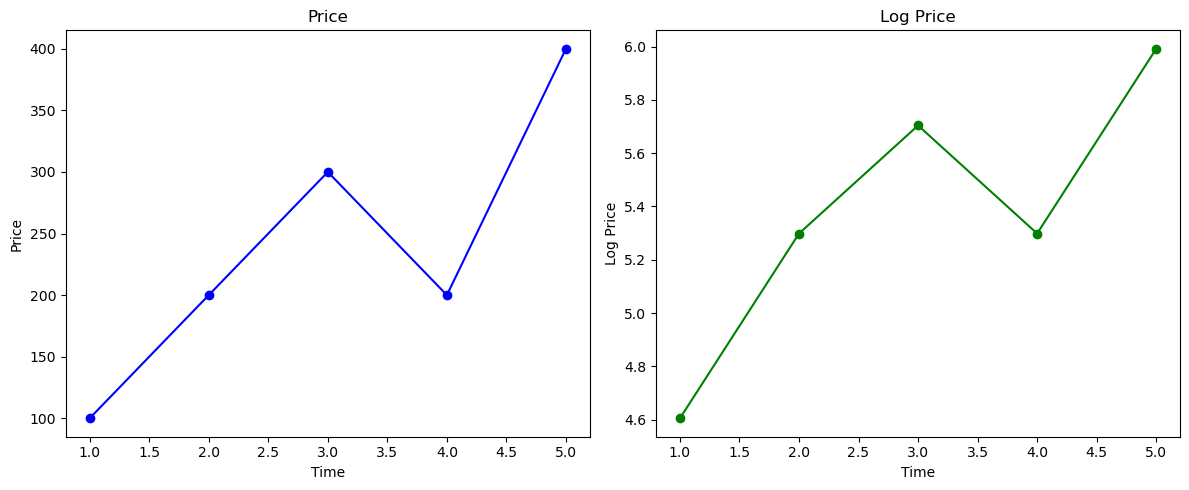

In [6]:
# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot price
axes[0].plot(df.index, df["price"], marker="o", color="blue")
axes[0].set_title("Price")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Price")

# Plot log price
axes[1].plot(df.index, df["log_price"], marker="o", color="green")
axes[1].set_title("Log Price")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Log Price")

plt.tight_layout()
plt.show()

With the price plot (left panel), what you'll notice is that the slope between time period 1 and 2 is different to the slope between t=4 and t=5. With the steeper slope, it looks like there is "more action" in the latter period. This is somewhat misleading since a gain from 100 to 200 is the same as from 200 to 400; it's simply doubling your money.

The log prices (right panel) shows the same slope for t=1 to 2 and t=4 to 5. Hence, log-prices make better sense visually!

## Adjusted Prices

You can get price data for many stocks and crypto currencies from Yahoo Finance!

If you know the ticker, for example, "NTFX" for Netflix, you can get historical data from the following [LINK](https://finance.yahoo.com/quote/NFLX/history/).

A more convenient way is to use the Yahoo Finance **API** from Python:

In [7]:
# !pip install yfinance
import yfinance as yf
df = yf.download('NFLX', start = '2015-1-1', end = '2026-4-10', auto_adjust = False)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,NFLX,NFLX,NFLX,NFLX,NFLX,NFLX
Date,,,,,,
2015-01-02,4.984857,4.984857,5.033143,4.873143,4.915143,134750000
2015-01-05,4.731143,4.731143,4.925857,4.714714,4.925857,181650000
2015-01-06,4.650143,4.650143,4.764000,4.566143,4.734714,160377000
2015-01-07,4.674286,4.674286,4.742143,4.627143,4.734714,98497000
2015-01-08,4.778000,4.778000,4.783571,4.647857,4.712000,96019000


<Axes: xlabel='Date'>

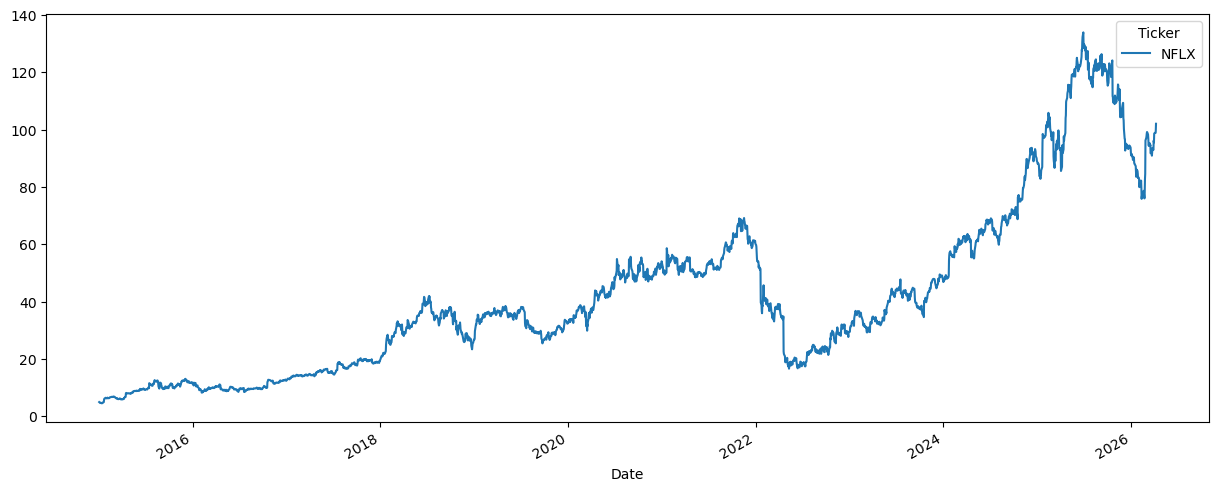

In [8]:
# Plot adjusted closing price
df['Adj Close'].plot(figsize = (15,6))

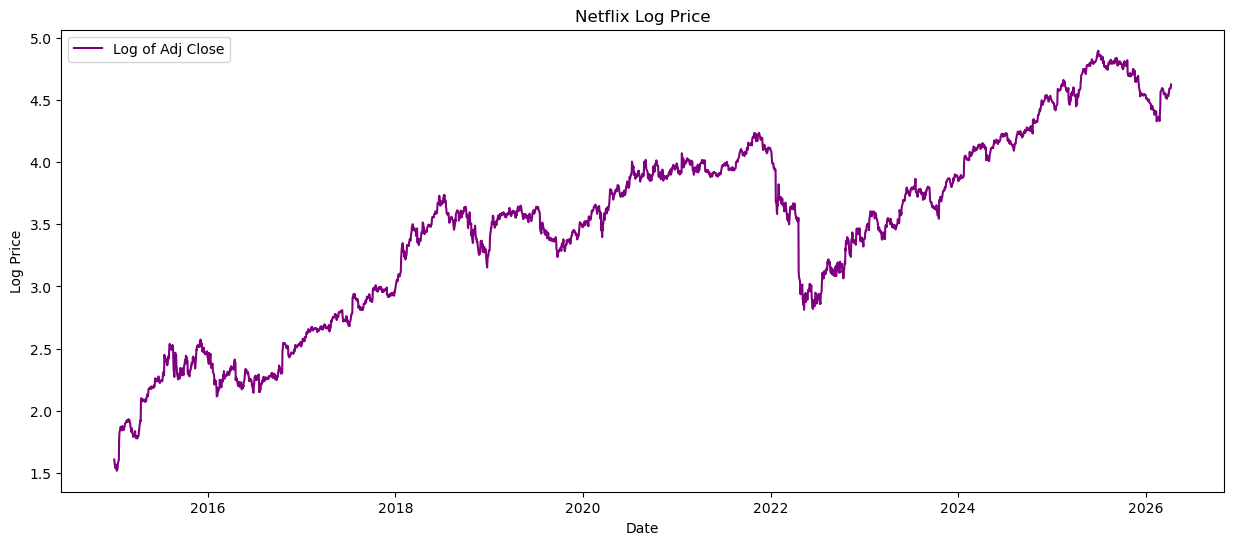

In [9]:
# Use 'Adj Close' for adjusted prices
df['LogPrice'] = np.log(df['Adj Close'])

# Plot log price
plt.figure(figsize=(15,6))
plt.plot(df.index, df['LogPrice'], color='purple', label="Log of Adj Close")
plt.title("Netflix Log Price")
plt.ylabel("Log Price")
plt.xlabel("Date")
plt.legend()
plt.show()

Looks quite different!

How about the returns versus log returns?

**Simple return:**

```{math}
R_t = \frac{P_t}{P_{t-1}} - 1
```

**Log return:**

```{math}
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
```

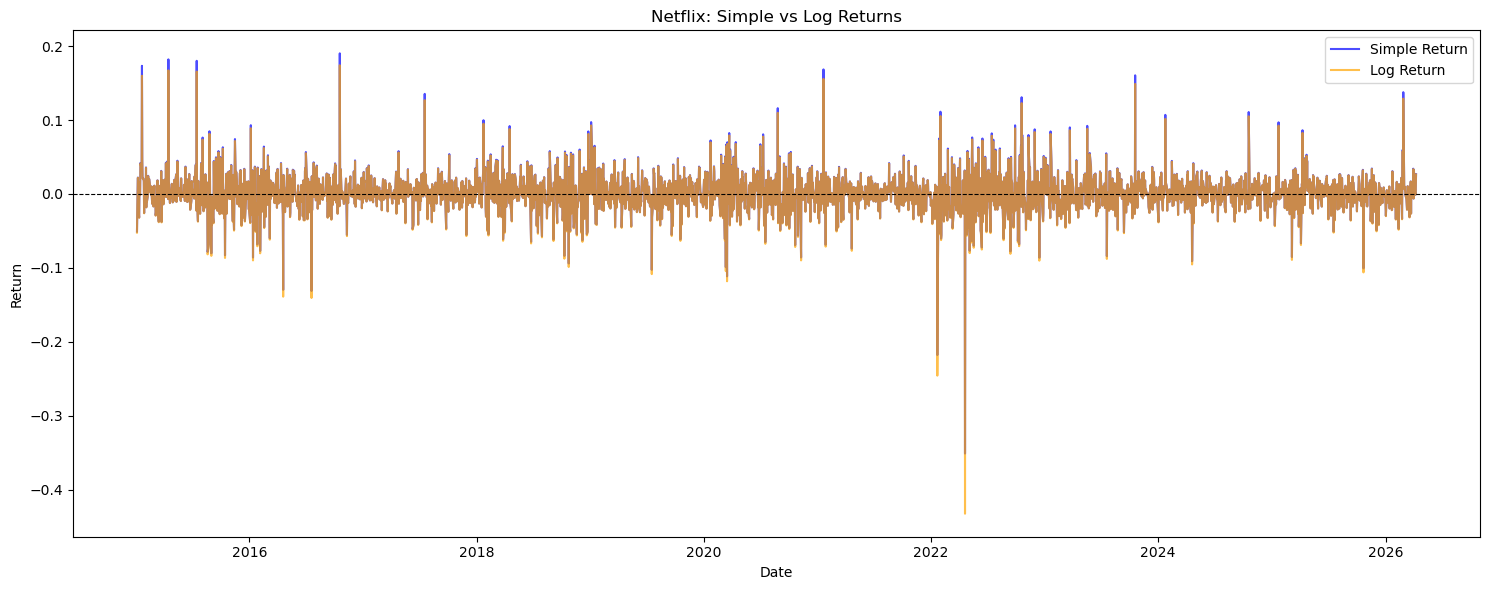

In [10]:
# Compute returns
df['SimpleReturn'] = df['Adj Close'].pct_change()   # (P_t / P_{t-1}) - 1
df['LogReturn'] = np.log(df['Adj Close'] / df['Adj Close'].shift(1))

# Plot both series
plt.figure(figsize=(15,6))
plt.plot(df.index, df['SimpleReturn'], label="Simple Return", color='blue', alpha=0.7)
plt.plot(df.index, df['LogReturn'], label="Log Return", color='orange', alpha=0.7)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.title("Netflix: Simple vs Log Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
plt.show()

Looks very close!

We will discuss log returns in depth in a later chapter. 

Note that Yahoo Finance provides **Adjusted** Close Price and Close Price.

The **Close Price** is simply the last trading price of a stock at the end of a trading day. The **Adjusted Close Price**, however, goes a step further: it modifies the close price to account for corporate actions that affect the stock’s value but aren’t reflected in the raw closing price.  

### Key Adjustments Included

- **Dividends**: Cash dividends reduce the stock’s value, so adjusted close reflects this.
- **Stock Splits**: If a company splits its shares (e.g., 2-for-1), the adjusted close recalculates past prices to maintain consistency.
- **Reverse Splits**: Similarly, reverse splits are factored in.
- **Other Corporate Actions**: Rights offerings or spin-offs may also be incorporated.

### Why It Matters

- **Comparability**: Adjusted close makes historical prices consistent, so you can accurately compare performance over time.
- **Total Return Analysis**: It reflects the real economic value to shareholders, including dividends and splits.
- **Charting & Backtesting**: Analysts and investors use adjusted close for technical analysis and historical performance studies.

Think of it this way:  

- **Close Price** = “What the market said at 4 PM today” = the raw market price at the end of the day. 
- **Adjusted Close Price** = “What that price really means after accounting for dividends and splits, so history is apples-to-apples” = the close price modified for dividends, splits, and similar corporate actions, so historical performance reflects the **true economic value** to shareholders.  

---
### 📊 Dividend Adjustment Example

Suppose a company’s stock closes at **Baht 100** on April 1.  
On April 2, the company pays a **Baht 2 dividend** and closes at **Baht 102**.

**Formula:**

```
Adjusted Close (Day 1) = 100 - 2 = 98
```

**Table:**

| Day   | Close Price | Adjusted Close |
|-------|-------------|----------------|
| April 1 | 100        | 98          |
| April 2 | 102        | 102         |
 

Why? Because after the dividend is paid, the stock’s value effectively drops by $2. The adjusted close retroactively reflects this so that historical prices remain consistent with shareholder value.

---

### 📊 Stock Split Adjustment Example

Suppose a company’s stock closes at **Baht 200** on Day 1, then on Day 2 it undergoes a **2-for-1 split** (each share becomes two shares at half the price). Close price on Day 2 is **Baht 220**, and on Day 3, it closes at **Baht 110**.

So we should work backwards ...

**Formula:**

```
Adjusted Close (Day 2) = 230 / 2 = 115
Adjusted Close (Day 1) = 200 / 2 = 100
```

**Table:**

| Day   | Close Price | Adjusted Close |
|-------|-------------|----------------|
| Day 1 | 200        | 100           |
| Day 2 | 230        | 115           |
| Day 3 | 110        | 110           |

Why? Because after the split, each share is worth half as much, but investors now hold twice as many shares. Adjusted close recalculates past prices to keep charts and performance comparisons meaningful.

The Adjusted Closing Prices are therefore recalibrated at the end of every day for each stock and provided through portals like Yahoo Finance!

So how do we get the closing price for the Open, High and Low prices? How about Adjusted Volume?